# Damaged Case Detection (Brightness Thresholding)

Notebook implementuje detekcje typu damaged_case poprzez analize jasnych pikseli wewnatrz ROI obudowy tranzystora.

In [13]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import sys

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Python:", sys.version.split()[0])
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 10

Python: 3.14.1
OpenCV: 4.13.0
NumPy: 2.4.4


In [ ]:
def find_project_dir(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "transistor").exists() and (candidate / "model.py").exists():
            return candidate
    raise FileNotFoundError("Nie znaleziono katalogu projektu (transistor + model.py).")

PROJECT_DIR = find_project_dir(Path.cwd())
TEST_DIR = PROJECT_DIR / "transistor" / "test"
REFERENCE_MASK_PATH = PROJECT_DIR / "reference_mask_vote_0.50.npy"

CLASS_NAMES = ["good", "bent_lead", "cut_lead", "damaged_case", "misplaced"]
DEFAULT_BRIGHTNESS_THRESHOLD = 80
DEFAULT_MIN_DEFECT_AREA = 120
DEFAULT_TOP_RATIO = 0.62
DEFAULT_ERODE_RATIO = 0.04
DEFAULT_ROI_MIN_AREA = 180

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import model as defect_model  # noqa: E402

REFERENCE_MASK = np.load(str(REFERENCE_MASK_PATH)).astype(np.uint8)

print("PROJECT_DIR:", PROJECT_DIR)
print("REFERENCE_MASK shape:", REFERENCE_MASK.shape)

PROJECT_DIR: C:\Users\MateuszOmen\Desktop\studia\sem6\zaawanasowane_algorytmy_wizyjne_projekty\Transformers\proj01
REFERENCE_MASK shape: (1024, 1024)


In [19]:
@dataclass
class PredictionRecord:
    cls_name: str
    image_path: Path
    predicted_damaged: bool
    true_damaged: bool
    brightness_threshold: int
    defect_area: int
    defect_ratio: float
    relative_threshold: float


def _ensure_binary_mask(mask: np.ndarray) -> np.ndarray:
    if mask.ndim != 2:
        raise ValueError("Maska musi byc 2D")
    return (mask > 0).astype(np.uint8) * 255


def _cleanup_components(mask: np.ndarray, min_area: int = 30) -> np.ndarray:
    binary = _ensure_binary_mask(mask)
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    out = np.zeros_like(binary)
    for idx in range(1, n_labels):
        if int(stats[idx, cv2.CC_STAT_AREA]) >= min_area:
            out[labels == idx] = 255
    return out


def _extract_core_mask(mask: np.ndarray, erode_ratio: float = DEFAULT_ERODE_RATIO) -> np.ndarray:
    binary = _ensure_binary_mask(mask)
    h, w = binary.shape
    kernel_size = int(round(min(h, w) * erode_ratio))
    kernel_size = max(3, min(21, kernel_size))
    if kernel_size % 2 == 0:
        kernel_size += 1

    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    core = cv2.erode(binary, kernel, iterations=1)
    if np.count_nonzero(core) == 0:
        return binary
    return core


def _narrow_black_case_roi(
    package_roi: np.ndarray,
    top_ratio: float = DEFAULT_TOP_RATIO,
    side_margin_ratio: float = 0.09,
) -> np.ndarray:
    """Zawęża ROI do górnej, czarnej części obudowy i ucina brzegi."""
    binary = _ensure_binary_mask(package_roi)
    h, w = binary.shape

    roi = binary.copy()
    y_max = int(h * top_ratio)
    roi[y_max:, :] = 0

    x_margin = int(w * side_margin_ratio)
    if x_margin > 0:
        roi[:, :x_margin] = 0
        roi[:, w - x_margin :] = 0

    roi = cv2.morphologyEx(roi, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    roi = _cleanup_components(roi, min_area=80)
    return roi


def load_rgb(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def iter_test_images(test_dir: Path, class_names: list[str]) -> Iterable[tuple[str, Path]]:
    for cls_name in class_names:
        for image_path in sorted((test_dir / cls_name).glob("*.png")):
            yield cls_name, image_path


def build_package_roi(
    test_mask: np.ndarray,
    reference_mask: np.ndarray,
    top_ratio: float = DEFAULT_TOP_RATIO,
    erode_ratio: float = DEFAULT_ERODE_RATIO,
) -> np.ndarray:
    if not (0.3 <= top_ratio <= 0.95):
        raise ValueError("top_ratio musi byc w przedziale [0.3, 0.95]")

    test_mask = _ensure_binary_mask(test_mask)
    reference_mask = _ensure_binary_mask(reference_mask)

    if test_mask.shape != reference_mask.shape:
        h, w = test_mask.shape
        reference_mask = cv2.resize(reference_mask, (w, h), interpolation=cv2.INTER_NEAREST)

    stable = cv2.bitwise_and(test_mask, reference_mask)
    stable = _extract_core_mask(stable, erode_ratio=erode_ratio)
    package_roi = _narrow_black_case_roi(stable, top_ratio=top_ratio)
    return package_roi


def compute_relative_brightness_threshold(
    gray: np.ndarray,
    roi_mask: np.ndarray,
    percentile: float = 92.0,
    delta: float = 18.0,
) -> float:
    roi = _ensure_binary_mask(roi_mask) > 0
    roi_values = gray[roi]
    if roi_values.size == 0:
        raise ValueError("ROI jest puste - nie da sie policzyc progu jasnosci")

    roi_values = roi_values.astype(np.float32)
    median_value = float(np.median(roi_values))
    percentile_value = float(np.percentile(roi_values, percentile))
    return max(median_value + float(delta), percentile_value)


def brightness_defect_mask(
    image_rgb: np.ndarray,
    package_roi: np.ndarray,
    brightness_threshold: int,
    relative_percentile: float = 92.0,
    relative_delta: float = 18.0,
) -> tuple[np.ndarray, float, np.ndarray]:
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    roi = _ensure_binary_mask(package_roi)

    effective_threshold = compute_relative_brightness_threshold(
        gray,
        roi,
        percentile=relative_percentile,
        delta=relative_delta,
    )
    effective_threshold = max(float(brightness_threshold), effective_threshold)

    bright = np.zeros_like(gray, dtype=np.uint8)
    bright[(roi > 0) & (gray >= effective_threshold)] = 255

    bright = cv2.morphologyEx(bright, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    bright = cv2.morphologyEx(bright, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8), iterations=1)
    return bright, float(effective_threshold), gray


def is_damaged_case(
    image: np.ndarray,
    brightness_threshold: int = DEFAULT_BRIGHTNESS_THRESHOLD,
    min_defect_area: int = DEFAULT_MIN_DEFECT_AREA,
    reference_mask: np.ndarray | None = None,
    precomputed_test_mask: np.ndarray | None = None,
    relative_percentile: float = 92.0,
    relative_delta: float = 18.0,
    return_debug: bool = False,
) -> bool | tuple[bool, dict]:
    if not isinstance(image, np.ndarray):
        raise TypeError("image musi byc np.ndarray")
    if image.ndim != 3 or image.shape[2] != 3:
        raise ValueError("image musi miec ksztalt (H, W, 3)")
    if image.dtype != np.uint8:
        image = np.clip(image, 0, 255).astype(np.uint8)

    if not (0 <= brightness_threshold <= 255):
        raise ValueError("brightness_threshold musi byc w [0, 255]")
    if min_defect_area < 1:
        raise ValueError("min_defect_area musi byc dodatnie")

    ref_mask = REFERENCE_MASK if reference_mask is None else reference_mask
    ref_mask = _ensure_binary_mask(ref_mask)

    if precomputed_test_mask is None:
        test_mask = defect_model._extract_transistor_mask(image)
    else:
        test_mask = _ensure_binary_mask(precomputed_test_mask)

    no_transistor_detected = np.count_nonzero(test_mask) == 0
    if no_transistor_detected:
        decision = False
        debug = {
            "no_transistor_detected": True,
            "empty_roi": True,
            "defect_area": 0,
            "defect_ratio": 0.0,
            "effective_threshold": float(brightness_threshold),
            "relative_threshold": float(brightness_threshold),
            "test_mask": test_mask,
            "package_roi": np.zeros_like(test_mask),
            "defect_mask": np.zeros_like(test_mask),
            "gray": np.zeros_like(test_mask),
        }
        return (decision, debug) if return_debug else decision

    package_roi = build_package_roi(test_mask, ref_mask)
    empty_roi = np.count_nonzero(package_roi) == 0
    if empty_roi:
        decision = False
        debug = {
            "no_transistor_detected": False,
            "empty_roi": True,
            "defect_area": 0,
            "defect_ratio": 0.0,
            "effective_threshold": float(brightness_threshold),
            "relative_threshold": float(brightness_threshold),
            "test_mask": test_mask,
            "package_roi": package_roi,
            "defect_mask": np.zeros_like(test_mask),
            "gray": np.zeros_like(test_mask),
        }
        return (decision, debug) if return_debug else decision

    defect_mask, effective_threshold, gray = brightness_defect_mask(
        image,
        package_roi,
        brightness_threshold=brightness_threshold,
        relative_percentile=relative_percentile,
        relative_delta=relative_delta,
    )
    defect_mask = _cleanup_components(defect_mask, min_area=min_defect_area)

    defect_area = int(np.count_nonzero(defect_mask))
    roi_area = int(np.count_nonzero(package_roi))
    defect_ratio = float(defect_area / max(roi_area, 1))

    decision = defect_area >= int(min_defect_area)

    if not return_debug:
        return decision

    debug = {
        "no_transistor_detected": False,
        "empty_roi": False,
        "defect_area": defect_area,
        "defect_ratio": defect_ratio,
        "effective_threshold": float(effective_threshold),
        "relative_threshold": float(effective_threshold),
        "test_mask": test_mask,
        "package_roi": package_roi,
        "defect_mask": defect_mask,
        "brightness_threshold": int(brightness_threshold),
        "min_defect_area": int(min_defect_area),
        "gray": gray,
    }
    return decision, debug


print("Funkcje bazowe zdefiniowane.")

Funkcje bazowe zdefiniowane.


In [20]:
# Testy jednostkowe
synthetic_ref = np.zeros((128, 128), dtype=np.uint8)
synthetic_ref[24:104, 24:104] = 255

synthetic_test = np.zeros((128, 128), dtype=np.uint8)
synthetic_test[24:104, 24:104] = 255

roi = build_package_roi(synthetic_test, synthetic_ref, top_ratio=0.6, erode_ratio=0.02)
assert np.count_nonzero(roi) > 0

img = np.zeros((128, 128, 3), dtype=np.uint8)
# Jasna plama w ROI (symulacja uszkodzenia)
img[40:52, 44:56, :] = 170

def_mask, eff_thr, gray = brightness_defect_mask(img, roi, brightness_threshold=80)
assert np.count_nonzero(def_mask) > 0
assert eff_thr >= 80
assert gray.shape == roi.shape

# Brak tranzystora -> nie klasyfikujemy jako damaged_case
empty_mask = np.zeros((128, 128), dtype=np.uint8)
decision, dbg = is_damaged_case(
    image=np.zeros((128, 128, 3), dtype=np.uint8),
    brightness_threshold=80,
    min_defect_area=30,
    reference_mask=synthetic_ref,
    precomputed_test_mask=empty_mask,
    return_debug=True,
)
assert decision is False
assert bool(dbg["no_transistor_detected"]) is True

print("Testy jednostkowe przeszly.")

Testy jednostkowe przeszly.


Najlepszy prog jasnosci: 80
Best metrics: {'tp': 9.0, 'fp': 56.0, 'tn': 21.0, 'fn': 0.0, 'precision': 0.13846153846153847, 'recall': 1.0, 'f1': 0.24324324324324326, 'accuracy': 0.3488372093023256}

Metryki dla wybranego progu: {'tp': 9.0, 'fp': 56.0, 'tn': 21.0, 'fn': 0.0, 'precision': 0.13846153846153847, 'recall': 1.0, 'f1': 0.24324324324324326, 'accuracy': 0.3488372093023256}

=== Podsumowanie per klasa ===
good         n= 50  mean_area=  922.42  mean_ratio= 0.0061  mean_rel_thr=  80.00  pred_rate= 0.720
bent_lead    n=  9  mean_area= 1262.89  mean_ratio= 0.0080  mean_rel_thr=  80.00  pred_rate= 0.889
cut_lead     n=  9  mean_area=  582.44  mean_ratio= 0.0037  mean_rel_thr=  80.00  pred_rate= 0.556
damaged_case n=  9  mean_area=  794.56  mean_ratio= 0.0056  mean_rel_thr=  80.00  pred_rate= 1.000
misplaced    n=  9  mean_area= 2764.33  mean_ratio= 0.0326  mean_rel_thr=  89.11  pred_rate= 0.778


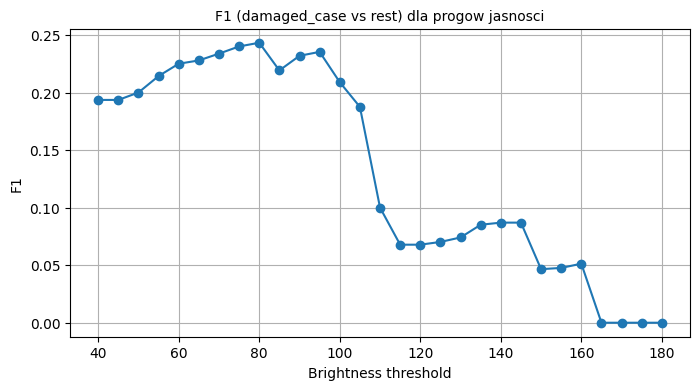

In [21]:
def evaluate_test_set(
    brightness_threshold: int = DEFAULT_BRIGHTNESS_THRESHOLD,
    min_defect_area: int = DEFAULT_MIN_DEFECT_AREA,
    relative_percentile: float = 92.0,
    relative_delta: float = 18.0,
) -> list[PredictionRecord]:
    records: list[PredictionRecord] = []
    for cls_name, image_path in iter_test_images(TEST_DIR, CLASS_NAMES):
        image = load_rgb(image_path)
        pred, dbg = is_damaged_case(
            image=image,
            brightness_threshold=brightness_threshold,
            min_defect_area=min_defect_area,
            reference_mask=REFERENCE_MASK,
            relative_percentile=relative_percentile,
            relative_delta=relative_delta,
            return_debug=True,
        )
        records.append(
            PredictionRecord(
                cls_name=cls_name,
                image_path=image_path,
                predicted_damaged=bool(pred),
                true_damaged=(cls_name == "damaged_case"),
                brightness_threshold=int(brightness_threshold),
                defect_area=int(dbg.get("defect_area", 0)),
                defect_ratio=float(dbg.get("defect_ratio", 0.0)),
                relative_threshold=float(dbg.get("effective_threshold", brightness_threshold)),
            )
        )
    return records


def confusion_from_records(records: list[PredictionRecord]) -> dict[str, float]:
    tp = sum(r.true_damaged and r.predicted_damaged for r in records)
    fp = sum((not r.true_damaged) and r.predicted_damaged for r in records)
    tn = sum((not r.true_damaged) and (not r.predicted_damaged) for r in records)
    fn = sum(r.true_damaged and (not r.predicted_damaged) for r in records)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    accuracy = (tp + tn) / max(len(records), 1)

    return {
        "tp": float(tp),
        "fp": float(fp),
        "tn": float(tn),
        "fn": float(fn),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "accuracy": float(accuracy),
    }


def summarize_by_class(records: list[PredictionRecord]) -> None:
    print("\n=== Podsumowanie per klasa ===")
    for cls_name in CLASS_NAMES:
        subset = [r for r in records if r.cls_name == cls_name]
        if not subset:
            continue
        mean_area = float(np.mean([r.defect_area for r in subset]))
        mean_ratio = float(np.mean([r.defect_ratio for r in subset]))
        mean_rel_thr = float(np.mean([r.relative_threshold for r in subset]))
        pred_rate = float(np.mean([r.predicted_damaged for r in subset]))
        print(f"{cls_name:12s} n={len(subset):3d}  mean_area={mean_area:8.2f}  mean_ratio={mean_ratio:7.4f}  mean_rel_thr={mean_rel_thr:7.2f}  pred_rate={pred_rate:6.3f}")


def sweep_thresholds(
    threshold_min: int = 40,
    threshold_max: int = 180,
    threshold_step: int = 5,
    min_defect_area: int = DEFAULT_MIN_DEFECT_AREA,
    relative_percentile: float = 92.0,
    relative_delta: float = 18.0,
) -> tuple[int, dict[str, float], list[tuple[int, float]]]:
    hist: list[tuple[int, float]] = []
    best_t = threshold_min
    best_metrics = {"f1": -1.0}

    for t in range(threshold_min, threshold_max + 1, threshold_step):
        rec = evaluate_test_set(
            brightness_threshold=t,
            min_defect_area=min_defect_area,
            relative_percentile=relative_percentile,
            relative_delta=relative_delta,
        )
        metrics = confusion_from_records(rec)
        hist.append((t, metrics["f1"]))
        if metrics["f1"] > best_metrics["f1"]:
            best_metrics = metrics
            best_t = t

    return best_t, best_metrics, hist


best_t, best_metrics, hist = sweep_thresholds(
    threshold_min=40,
    threshold_max=180,
    threshold_step=5,
    min_defect_area=DEFAULT_MIN_DEFECT_AREA,
    relative_percentile=92.0,
    relative_delta=18.0,
)
print("Najlepszy prog jasnosci:", best_t)
print("Best metrics:", best_metrics)

records = evaluate_test_set(
    brightness_threshold=best_t,
    min_defect_area=DEFAULT_MIN_DEFECT_AREA,
    relative_percentile=92.0,
    relative_delta=18.0,
)
metrics = confusion_from_records(records)
print("\nMetryki dla wybranego progu:", metrics)
summarize_by_class(records)

plt.figure(figsize=(8, 4))
plt.plot([x for x, _ in hist], [y for _, y in hist], marker="o")
plt.title("F1 (damaged_case vs rest) dla progow jasnosci")
plt.xlabel("Brightness threshold")
plt.ylabel("F1")
plt.grid(True)
plt.show()

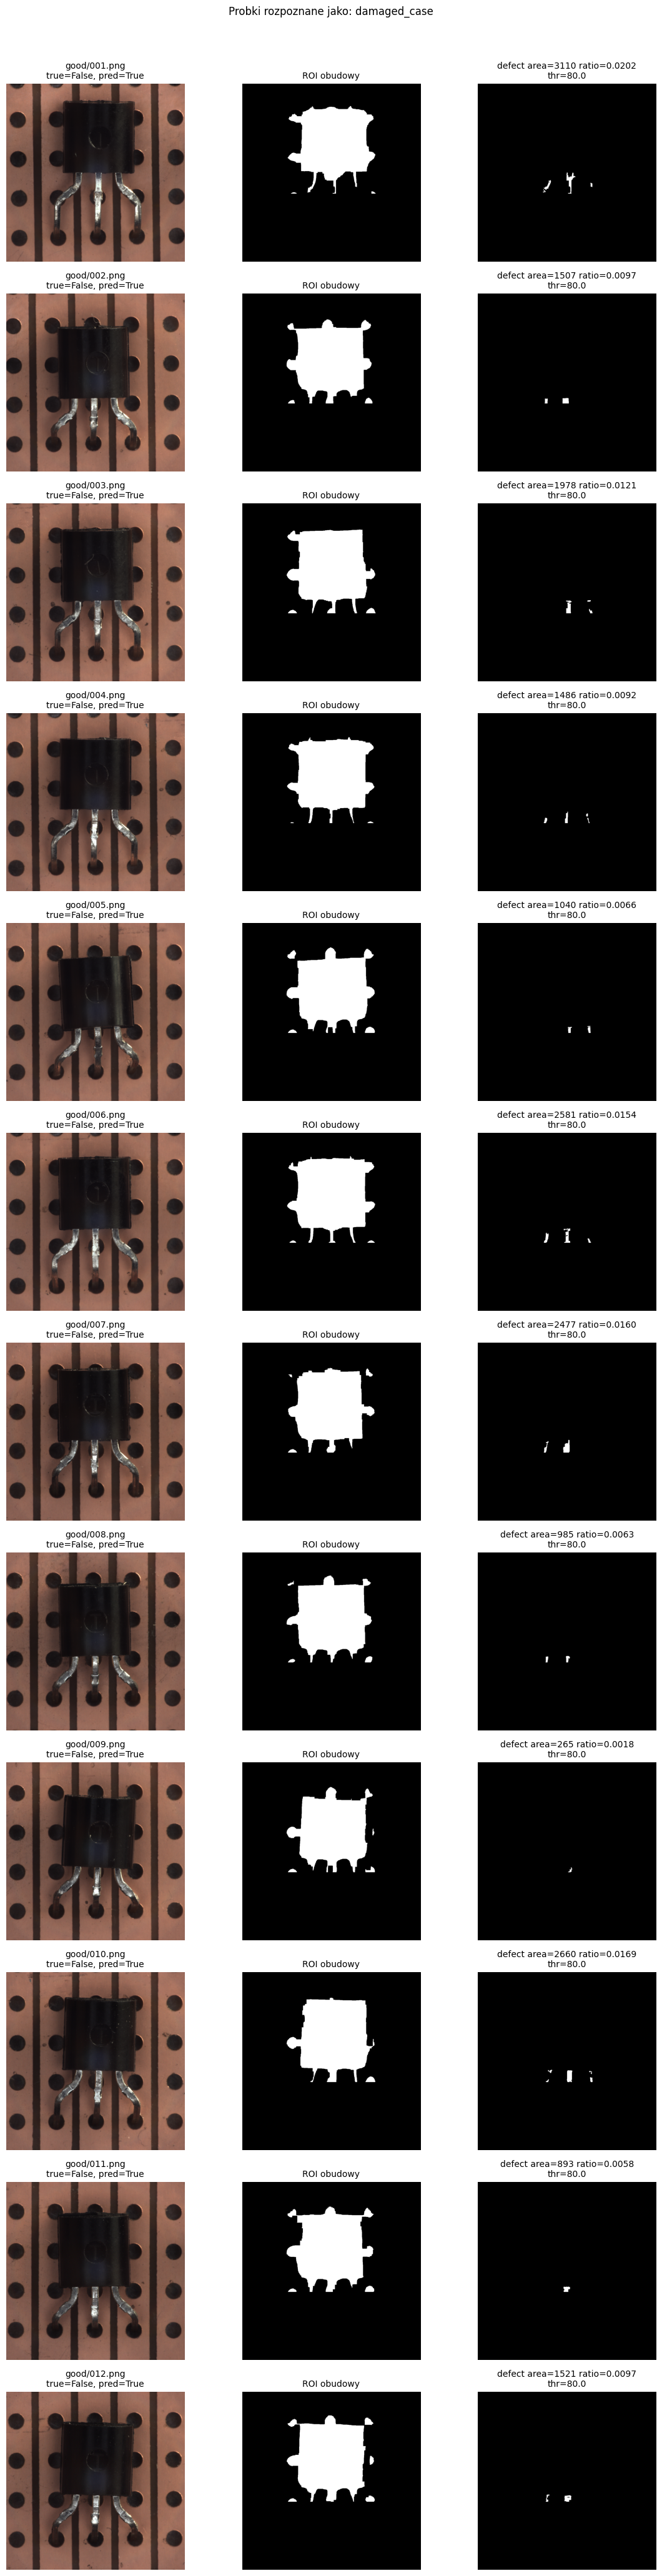

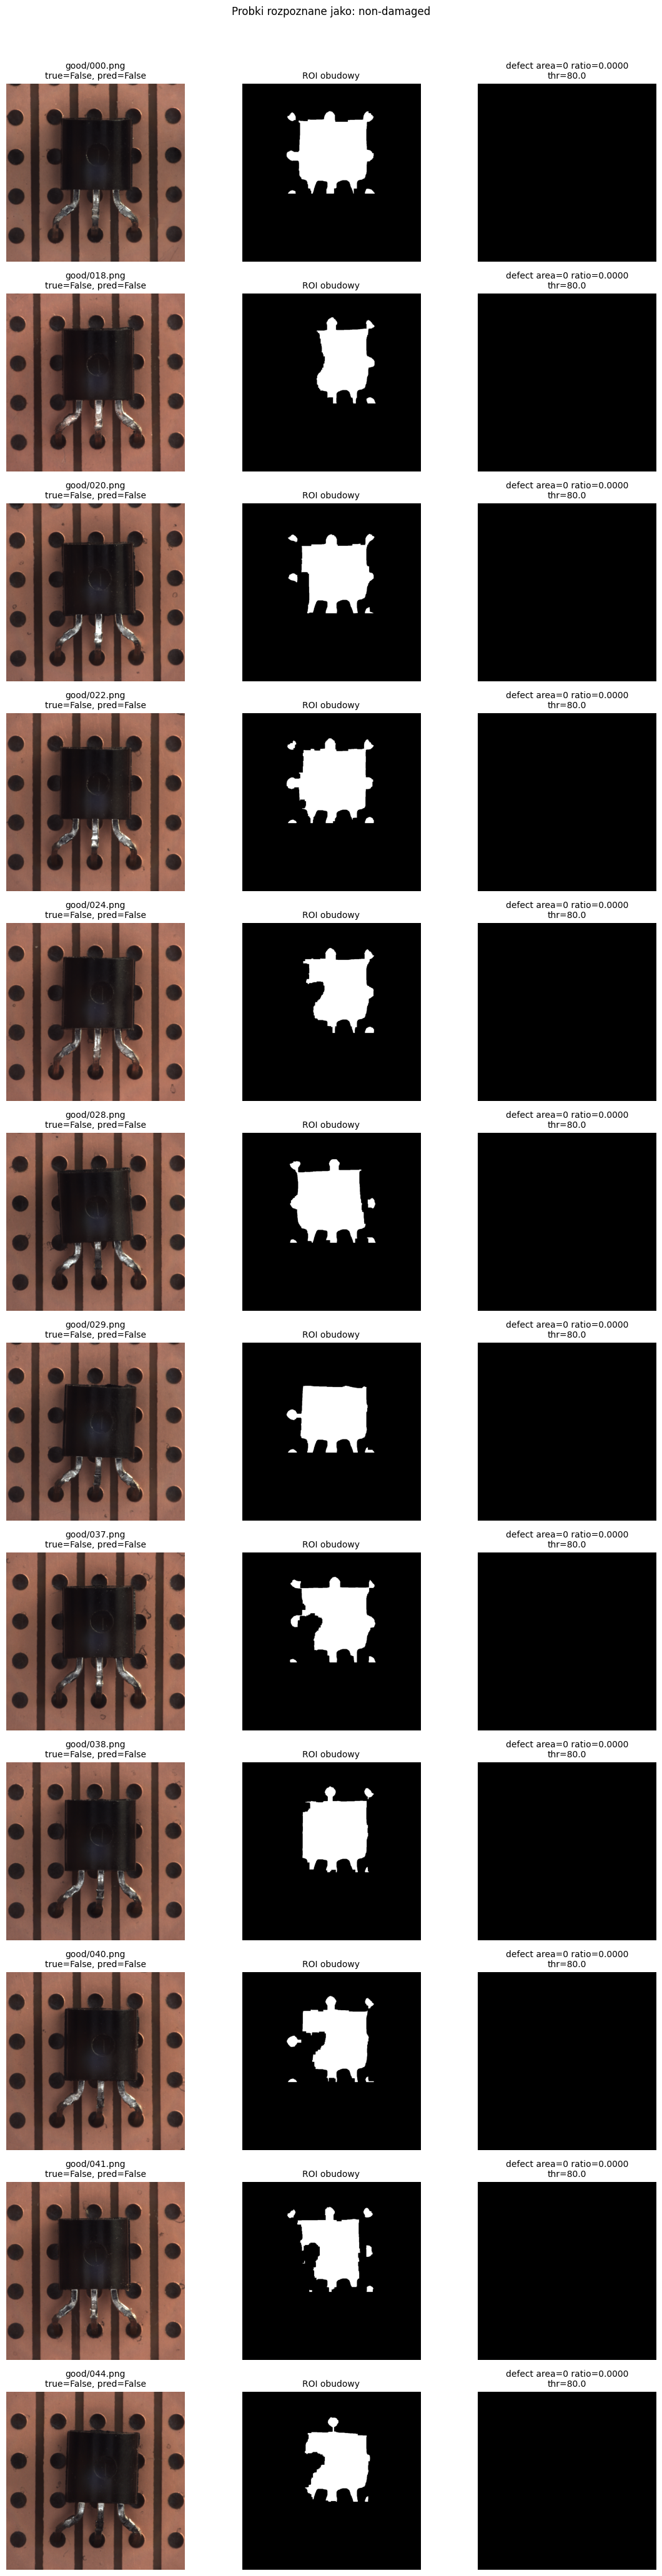

False Positive: 8 | False Negative: 0

--- False Positives ---


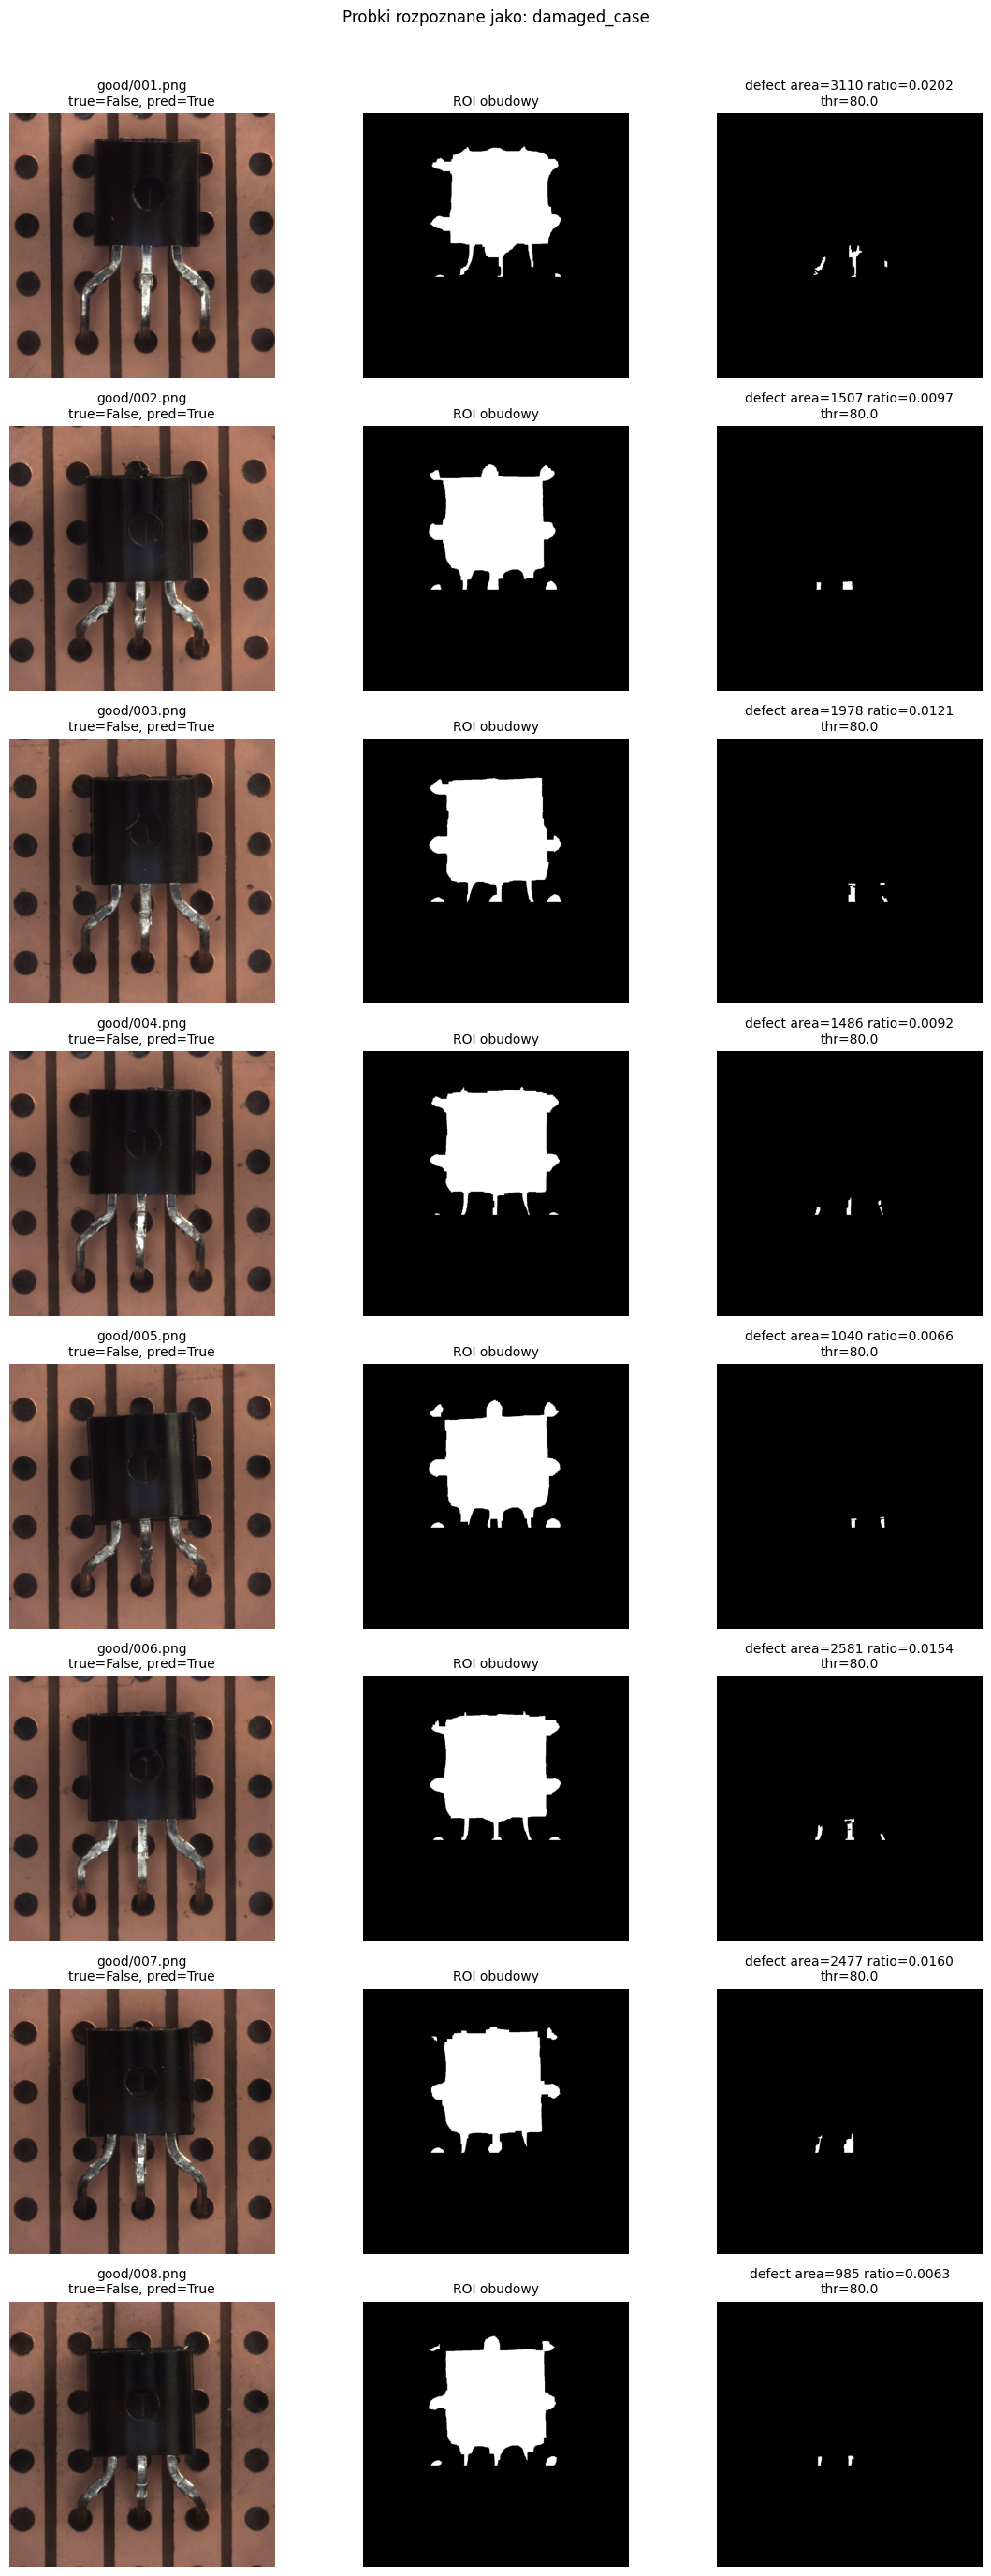

In [18]:
def visualize_predictions(records: list[PredictionRecord], predicted_value: bool, max_items: int = 10) -> None:
    selected = [r for r in records if r.predicted_damaged == predicted_value][:max_items]
    group_name = "damaged_case" if predicted_value else "non-damaged"

    if not selected:
        print(f"Brak probek dla grupy: {group_name}")
        return

    n = len(selected)
    fig, axes = plt.subplots(n, 3, figsize=(12, 3.4 * n))
    if n == 1:
        axes = np.array([axes])

    for i, rec in enumerate(selected):
        img = load_rgb(rec.image_path)
        pred, dbg = is_damaged_case(
            image=img,
            brightness_threshold=rec.brightness_threshold,
            min_defect_area=DEFAULT_MIN_DEFECT_AREA,
            reference_mask=REFERENCE_MASK,
            relative_percentile=92.0,
            relative_delta=18.0,
            return_debug=True,
        )

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(
            f"{rec.image_path.parent.name}/{rec.image_path.name}\n"
            f"true={rec.true_damaged}, pred={pred}"
        )
        axes[i, 0].axis("off")

        axes[i, 1].imshow(dbg["package_roi"], cmap="gray", vmin=0, vmax=255)
        axes[i, 1].set_title("ROI obudowy")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(dbg["defect_mask"], cmap="gray", vmin=0, vmax=255)
        axes[i, 2].set_title(
            f"defect area={dbg['defect_area']} ratio={dbg['defect_ratio']:.4f}\n"
            f"thr={dbg.get('effective_threshold', rec.brightness_threshold):.1f}"
        )
        axes[i, 2].axis("off")

    plt.suptitle(f"Probki rozpoznane jako: {group_name}", y=1.01)
    plt.tight_layout()
    plt.show()


def visualize_errors(records: list[PredictionRecord], max_items: int = 8) -> None:
    fp = [r for r in records if (not r.true_damaged) and r.predicted_damaged][:max_items]
    fn = [r for r in records if r.true_damaged and (not r.predicted_damaged)][:max_items]

    print(f"False Positive: {len(fp)} | False Negative: {len(fn)}")

    if fp:
        print("\n--- False Positives ---")
        visualize_predictions(fp, predicted_value=True, max_items=max_items)
    if fn:
        print("\n--- False Negatives ---")
        visualize_predictions(fn, predicted_value=False, max_items=max_items)


visualize_predictions(records, predicted_value=True, max_items=12)
visualize_predictions(records, predicted_value=False, max_items=12)
visualize_errors(records, max_items=8)